#**ASSIGNMENT 2 : NATURAL LANGUAGE PROCESSING (NLP)**

###Colab Link: https://colab.research.google.com/drive/1QrOwNiXACHWzmhCcutWfxqKRAj99qLit?usp=sharing
###Dataset:

A binary sentiment classification benchmark introduced in Maas et al., ACL 2011. Also known as aclImdb or simply IMDB.

This dataset contains 50,000 polarized movie reviews scraped from IMDB — 25,000 for training and 25,000 for testing — plus 50,000 additional unlabeled reviews for unsupervised or semi-supervised learning. Reviews are labeled only when strongly positive (score ≥ 7/10) or strongly negative (score ≤ 4/10), so the resulting classification task is challenging but unambiguous. Both raw text and pre-processed bag-of-words formats are provided.

## Q1: Task Definition and NLP Background

**Text Classification** — assigning predefined categories/labels to text (e.g. spam
detection, news categorization, sentiment labeling).

**Text Clustering** — grouping similar text together without predefined labels, based on
patterns in word usage (e.g. customer feedback grouping, topic discovery, document
organization).

**Sentiment Analysis** — determining the emotional tone of text, typically positive or
negative (e.g. product review analysis, social media monitoring, customer satisfaction
tracking).

In this notebook, all three tasks are applied to the IMDB movie review dataset:
classification and sentiment analysis predict positive/negative labels, while clustering
explores natural groupings in review text without using the sentiment labels.

## Q2: Data Loading, Inspecting and Preprocessing

In [1]:
#import neccessary libraries
import os, shutil, re, string, kagglehub, warnings, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import tensorflow as tf
warnings.filterwarnings("ignore") #hide harmless warnings to keep output clean


#classic natural language toolkit
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# set all random seeds and enable deterministic operations for full reproducibility
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()


sns.set_theme(style="whitegrid")
%matplotlib inline

# download nltk resources needed for tokenization, stopwords, and lemmatization
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [2]:
# download the IMDB dataset directly from kaggle
dataset_path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print(f"Dataset downloaded to: {dataset_path}")

# copy the csv file into the working directory
file_name = "IMDB Dataset.csv"
source_path = os.path.join(dataset_path, file_name)
shutil.copy(source_path, file_name)

df = pd.read_csv(file_name)
display (df.shape)
display(df.head())

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset downloaded to: /kaggle/input/imdb-dataset-of-50k-movie-reviews


(50000, 2)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


###Exploratory Data Analysis (EDA)

In [3]:
# check dataset shape and column data types
print(f"Dataset shape: {df.shape}")
print("\nColumn data types:")
print(df.dtypes)

Dataset shape: (50000, 2)

Column data types:
review       object
sentiment    object
dtype: object


In [4]:
# check for missing values in each column
missing_values = df.isnull().sum()
print(missing_values)

review       0
sentiment    0
dtype: int64


In [5]:
# check for duplicate reviews
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate records: {duplicate_count}")

# remove duplicates
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

Number of duplicate records: 418
Shape after removing duplicates: (49582, 2)


Class distribution:
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


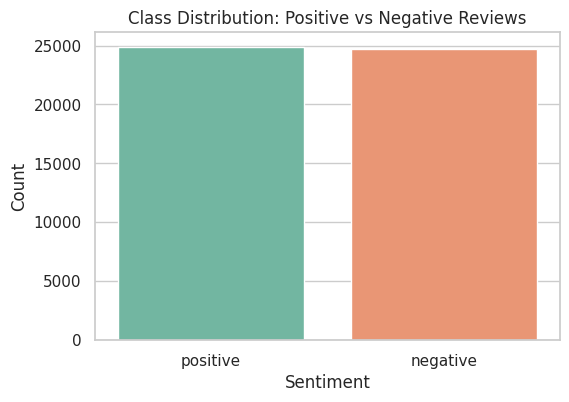

In [6]:
# check the balance of positive vs negative sentiment labels
print("Class distribution:")
print(df['sentiment'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df, palette='Set2')
plt.title("Class Distribution: Positive vs Negative Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [7]:
# combine all raw reviews into one long string for word frequency analysis
all_words_raw = ' '.join(df['review']).lower().split()

# get the most common words before any cleaning
frequency_distribution_raw = nltk.FreqDist(all_words_raw)
print("Top 20 most common words (raw, uncleaned text):")
print(frequency_distribution_raw.most_common(20))

Top 20 most common words (raw, uncleaned text):
[('the', 633981), ('a', 314408), ('and', 311378), ('of', 284608), ('to', 262599), ('is', 203488), ('in', 178487), ('i', 140393), ('this', 137398), ('that', 129179), ('it', 128655), ('/><br', 100211), ('was', 92494), ('as', 87592), ('with', 83950), ('for', 83880), ('but', 77270), ('on', 62404), ('movie', 61011), ('are', 56594)]


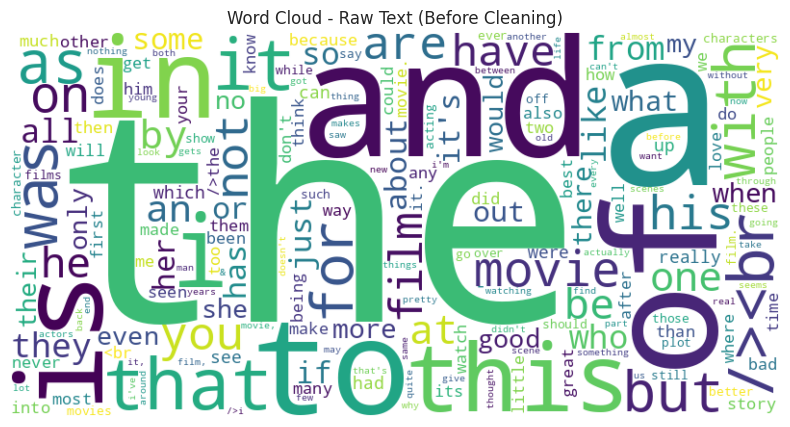

In [8]:
# generate a word cloud from the raw uncleaned text
wordcloud_raw = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(frequency_distribution_raw)

#plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_raw, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Raw Text (Before Cleaning)")
plt.show()

### Text Preprocessing

In [9]:
# remove html tags and punctuation from review text
def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)
    text = ''.join([i for i in text if i not in string.punctuation])
    return text

df.loc[:, 'cleaned_text'] = df['review'].apply(clean_text)

In [10]:
# tokenize text and convert to lower case
def tokenize_and_lower(text):
    word_tokens = word_tokenize(text)
    word_tokens_lowered = [word.lower() for word in word_tokens]
    return word_tokens_lowered

df.loc[:, 'tokenized_lowered'] = df['cleaned_text'].apply(tokenize_and_lower)

In [11]:
# remove common stopwords like 'the', 'is', 'a'
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return filtered_tokens
df.loc[:, 'rm_stopwords'] = df['tokenized_lowered'].apply(remove_stopwords)

In [12]:
# reduce words to their root form
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return lemmatized_tokens

df.loc[:, 'lemmatized'] = df['rm_stopwords'].apply(lemmatize_tokens)

In [13]:
# join lemmatized tokens back into a single string for vectorization
df.loc[:, 'clean_text'] = df['lemmatized'].apply(lambda x: ' '.join(x))
display(df[['review', 'clean_text']].head())

,review,clean_text
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching 1 oz episode y...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


Top 20 most common words (after cleaning):
[('movie', 100180), ('film', 90937), ('one', 53404), ('like', 39683), ('time', 29981), ('good', 28827), ('character', 27746), ('story', 24572), ('even', 24381), ('get', 24323), ('would', 23838), ('see', 23491), ('make', 23464), ('really', 22840), ('scene', 20937), ('well', 19246), ('much', 18944), ('people', 18044), ('great', 17890), ('bad', 17810)]


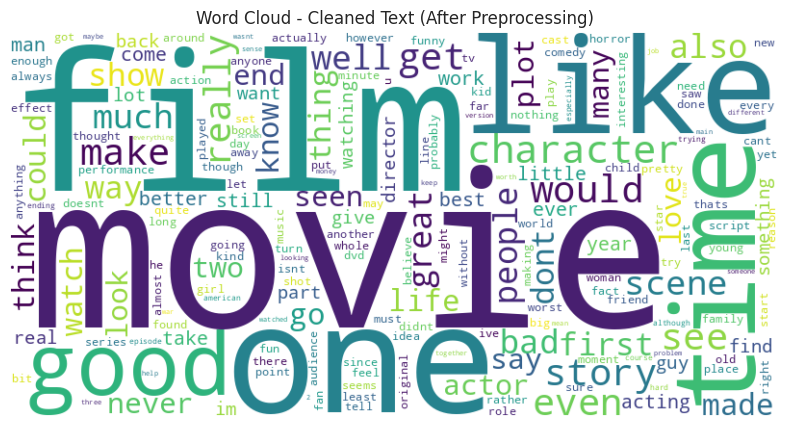

In [14]:
# check most common words after cleaning, for comparison against the raw version
all_words_clean = ' '.join(df['clean_text']).split()
frequency_distribution_clean = nltk.FreqDist(all_words_clean)
print("Top 20 most common words (after cleaning):")
print(frequency_distribution_clean.most_common(20))

# generate word cloud from cleaned text
wordcloud_clean = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(frequency_distribution_clean)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_clean, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Cleaned Text (After Preprocessing)")
plt.show()

In [15]:
# split into train and test sets before vectorization, to avoid data leakage
X_text = df['clean_text']
y = df['sentiment']
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set size: {X_train_text.shape[0]}")
print(f"Testing set size: {X_test_text.shape[0]}")

Training set size: 39665
Testing set size: 9917


In [16]:
# vectorization
tfidf = TfidfVectorizer()
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print(f"TF-IDF training matrix shape: {X_train.shape}")
print(f"TF-IDF testing matrix shape: {X_test.shape}")

TF-IDF training matrix shape: (39665, 136532)
TF-IDF testing matrix shape: (9917, 136532)


### Q3:Text Classification Models

We train three different models on the same TF-IDF features to compare how well each one
classifies positive vs negative reviews: Logistic Regression, Multinomial Naive Bayes, and
Linear SVM. Each model is evaluated using accuracy, precision, recall, and F1-score, plus a
confusion matrix to see where it makes mistakes.

In [17]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

# compute accuracy, precision, recall, and f1-score for a model's predictions
def get_metrics(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    return accuracy, precision, recall, f1

In [18]:
# plot a confusion matrix heatmap for a model's predictions
def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Logistic Regression - Accuracy: 0.8925, Precision: 0.8929, Recall: 0.8925, F1: 0.8925
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4940
    positive       0.88      0.91      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



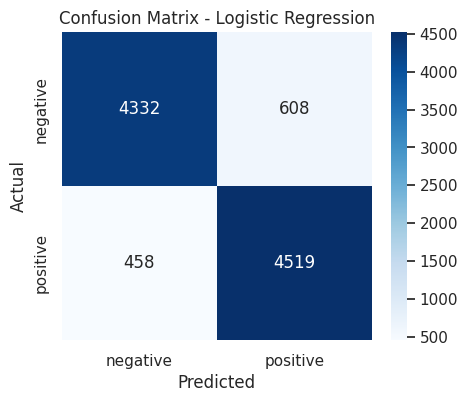

In [19]:
# train logistic regression model
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)

# evaluate the model
acc_log_reg, prec_log_reg, rec_log_reg, f1_log_reg = get_metrics(y_test, y_pred_log_reg)
print(f"Logistic Regression - Accuracy: {acc_log_reg:.4f}, Precision: {prec_log_reg:.4f}, Recall: {rec_log_reg:.4f}, F1: {f1_log_reg:.4f}")
print(classification_report(y_test, y_pred_log_reg, zero_division=0))
plot_confusion_matrix(y_test, y_pred_log_reg, "Logistic Regression")

Naive Bayes - Accuracy: 0.8666, Precision: 0.8668, Recall: 0.8666, F1: 0.8666
              precision    recall  f1-score   support

    negative       0.86      0.88      0.87      4940
    positive       0.88      0.85      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



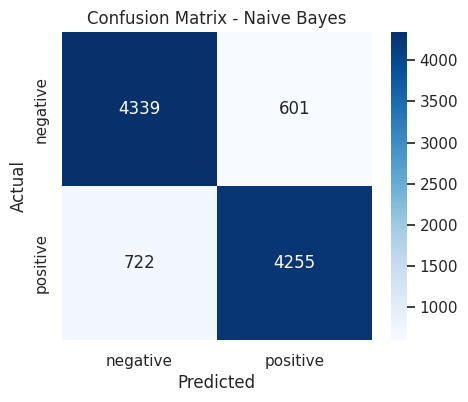

In [20]:
# train multinomial naive bayes model
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

# evaluate the model
acc_nb, prec_nb, rec_nb, f1_nb = get_metrics(y_test, y_pred_nb)
print(f"Naive Bayes - Accuracy: {acc_nb:.4f}, Precision: {prec_nb:.4f}, Recall: {rec_nb:.4f}, F1: {f1_nb:.4f}")
print(classification_report(y_test, y_pred_nb, zero_division=0))
plot_confusion_matrix(y_test, y_pred_nb, "Naive Bayes")

Linear SVM - Accuracy: 0.8954, Precision: 0.8955, Recall: 0.8954, F1: 0.8954
              precision    recall  f1-score   support

    negative       0.90      0.89      0.89      4940
    positive       0.89      0.90      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



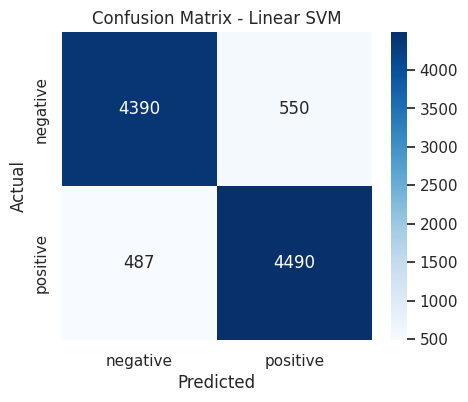

In [21]:
# train linear svm model
from sklearn.svm import LinearSVC
svm = LinearSVC(random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

# evaluate the model
acc_svm, prec_svm, rec_svm, f1_svm = get_metrics(y_test, y_pred_svm)
print(f"Linear SVM - Accuracy: {acc_svm:.4f}, Precision: {prec_svm:.4f}, Recall: {rec_svm:.4f}, F1: {f1_svm:.4f}")
print(classification_report(y_test, y_pred_svm, zero_division=0))
plot_confusion_matrix(y_test, y_pred_svm, "Linear SVM")

In [22]:
# combine all three models' metrics into one comparison table
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Linear SVM'],
    'Accuracy': [acc_log_reg, acc_nb, acc_svm],
    'Precision': [prec_log_reg, prec_nb, prec_svm],
    'Recall': [rec_log_reg, rec_nb, rec_svm],
    'F1-Score': [f1_log_reg, f1_nb, f1_svm]
})
display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.892508,0.892855,0.892508,0.892477
1,Naive Bayes,0.866593,0.866823,0.866593,0.866579
2,Linear SVM,0.895432,0.895491,0.895432,0.895425


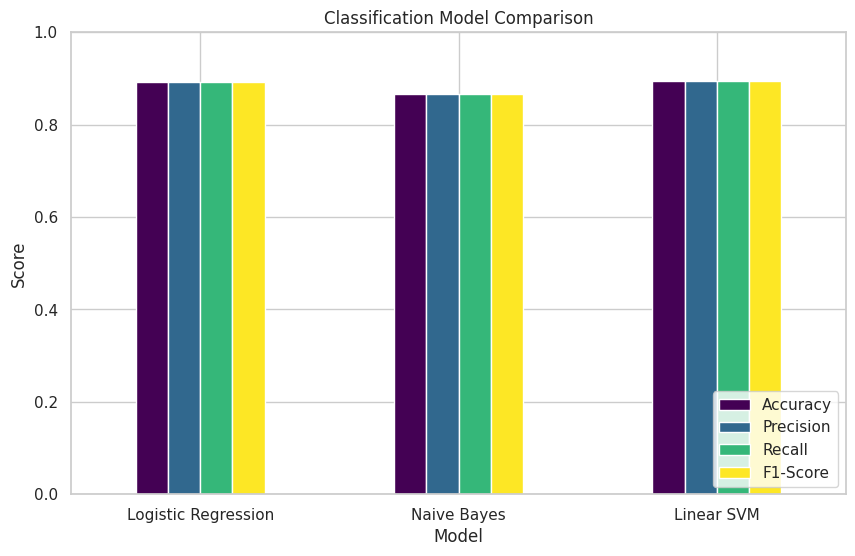

In [23]:
# visualize model comparison across all metrics
comparison_df.set_index('Model').plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title("Classification Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()

## Q4: Clustering

We reduce the TF-IDF features down to 2 dimensions using TruncatedSVD (the sparse-data
equivalent of PCA), then apply three different clustering algorithms — KMeans,
Agglomerative Clustering, and Gaussian Mixture Model (GMM) — to see how reviews
naturally group together based on word usage.

In [24]:
# reduce tfidf features to 2 dimensions for clustering and visualization
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=42)
X_reduced = svd.fit_transform(X_train)
print(f"Reduced shape: {X_reduced.shape}")

Reduced shape: (39665, 2)


###K-MEANS CLUSTERING

k=2, WCSS: 12.80, Silhouette Score: 0.4504
k=3, WCSS: 8.70, Silhouette Score: 0.3833
k=4, WCSS: 6.83, Silhouette Score: 0.3652
k=5, WCSS: 5.79, Silhouette Score: 0.3659
k=6, WCSS: 5.01, Silhouette Score: 0.3396
k=7, WCSS: 4.22, Silhouette Score: 0.3325
k=8, WCSS: 3.81, Silhouette Score: 0.3174


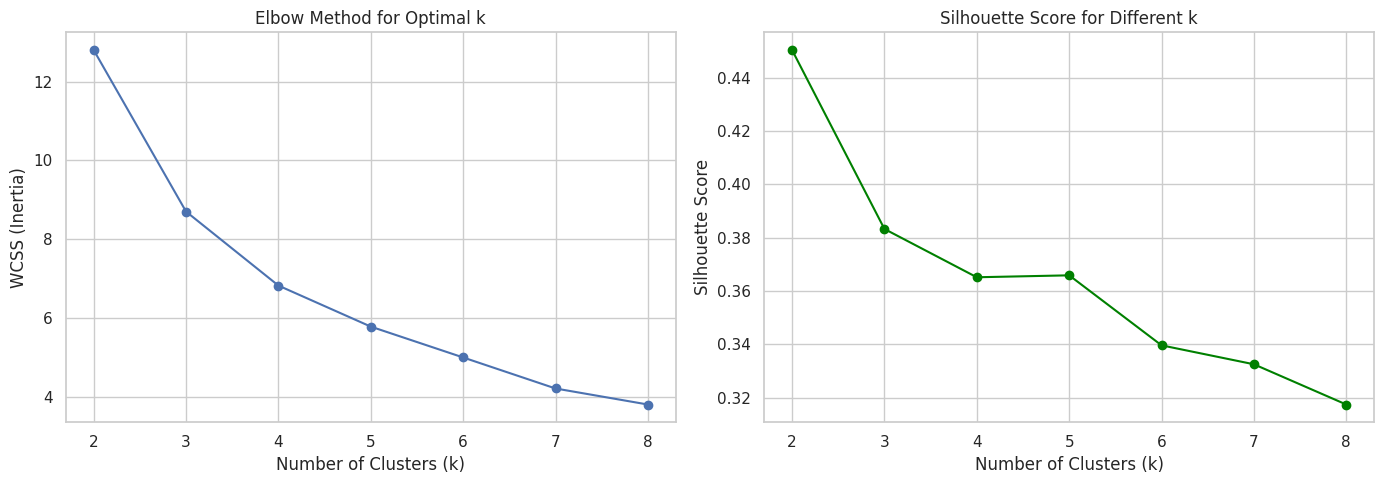

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# take a subsample for speed since we're testing multiple k values
np.random.seed(42)
sample_idx_k = np.random.choice(X_reduced.shape[0], size=3000, replace=False)
X_sample_k = X_reduced[sample_idx_k]

# compute wcss and silhouette score for each k
k_range = range(2, 9)
wcss = []
silhouette_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_sample_k)
    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_sample_k, labels))
    print(f"k={k}, WCSS: {km.inertia_:.2f}, Silhouette Score: {silhouette_scores[-1]:.4f}")

# plot both curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, wcss, marker='o')
axes[0].set_title("Elbow Method for Optimal k")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("WCSS (Inertia)")
axes[1].plot(k_range, silhouette_scores, marker='o', color='green')
axes[1].set_title("Silhouette Score for Different k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

In [26]:
# fit kmeans using k chosen from the elbow curve, e selected k=2 as this shows highest silhouette score
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
kmeans_labels = kmeans.fit_predict(X_reduced)
print("KMeans cluster sizes:")
print(pd.Series(kmeans_labels).value_counts())

KMeans cluster sizes:
0    28242
1    11423
Name: count, dtype: int64


In [27]:
# evaluate cluster quality using silhouette score
kmeans_silhouette = silhouette_score(X_reduced, kmeans_labels)
print(f"KMeans Silhouette Score: {kmeans_silhouette:.4f}")

KMeans Silhouette Score: 0.4359


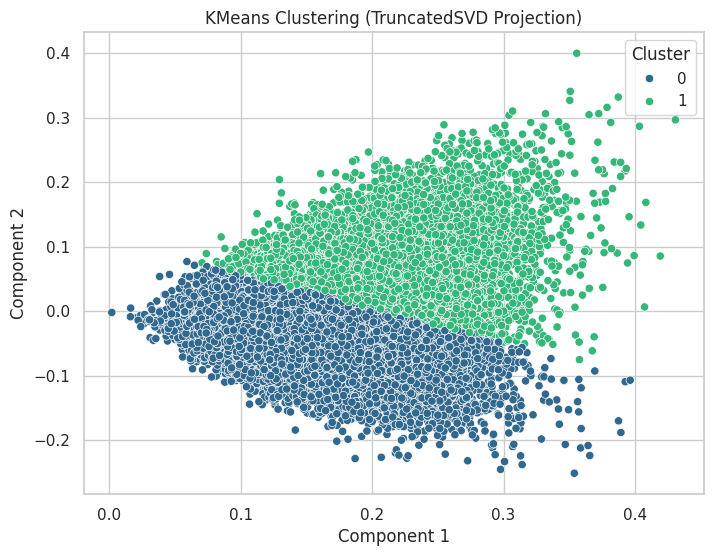

In [28]:
# visualize kmeans clusters in 2d
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_reduced[:, 0], y=X_reduced[:, 1], hue=kmeans_labels, palette='viridis')
plt.title("KMeans Clustering (TruncatedSVD Projection)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Cluster")
plt.show()

## Agglomerative Clustering



In [29]:
#Subsample
np.random.seed(42)
sample_idx = np.random.choice(X_reduced.shape[0], size=3000, replace=False)
X_sample = X_reduced[sample_idx]

In [30]:
# fit agglomerative clustering on the subsample
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(n_clusters=2)
agglo_labels = agglo.fit_predict(X_sample)
print("Agglomerative cluster sizes:")
print(pd.Series(agglo_labels).value_counts())

Agglomerative cluster sizes:
0    2118
1     882
Name: count, dtype: int64


In [31]:
# evaluate cluster quality using silhouette score
agglo_silhouette = silhouette_score(X_sample, agglo_labels)
print(f"Agglomerative Silhouette Score: {agglo_silhouette:.4f}")

Agglomerative Silhouette Score: 0.3873


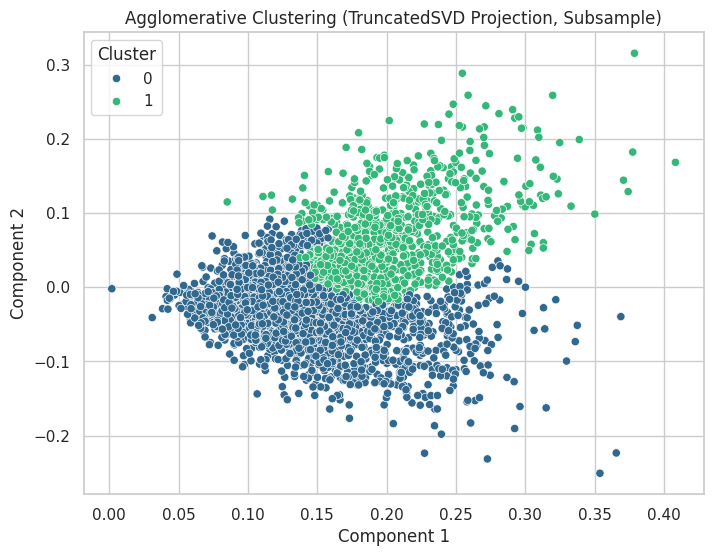

In [32]:
# visualize agglomerative clusters in 2d
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_sample[:, 0], y=X_sample[:, 1], hue=agglo_labels, palette='viridis')
plt.title("Agglomerative Clustering (TruncatedSVD Projection, Subsample)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Cluster")
plt.show()

## Gaussian Mixture Model (GMM)



In [33]:
# fit gaussian mixture model on the full reduced dataset
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2, random_state=42)
gmm_labels = gmm.fit_predict(X_reduced)
print("GMM cluster sizes:")
print(pd.Series(gmm_labels).value_counts())

GMM cluster sizes:
0    28481
1    11184
Name: count, dtype: int64


In [34]:
# evaluate cluster quality using silhouette score
gmm_silhouette = silhouette_score(X_reduced, gmm_labels)
print(f"GMM Silhouette Score: {gmm_silhouette:.4f}")

GMM Silhouette Score: 0.4348


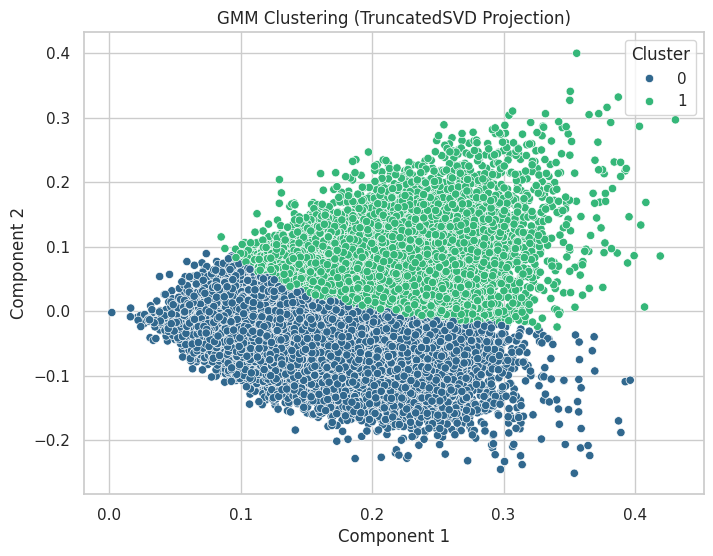

In [35]:
# visualize gmm clusters in 2d
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_reduced[:, 0], y=X_reduced[:, 1], hue=gmm_labels, palette='viridis')
plt.title("GMM Clustering (TruncatedSVD Projection)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Cluster")
plt.show()

In [36]:
# compare silhouette scores between three clustering algorithms
clustering_comparison_df = pd.DataFrame({
    'Algorithm': ['KMeans', 'Agglomerative', 'GMM'],
    'Silhouette Score': [kmeans_silhouette, agglo_silhouette, gmm_silhouette]
})
display(clustering_comparison_df)

,Algorithm,Silhouette Score
0,KMeans,0.435915
1,Agglomerative,0.387315
2,GMM,0.434765


## Q5: Sentiment Analysis

We compare three different approaches to sentiment analysis on the same test set: a lexicon-based model (VADER), a machine learning model (Logistic Regression, reused from Q3), and a deep learning model (LSTM). Each is evaluated using the same metrics so their performance can be fairly compared.

### Lexicon-Based: VADER

VADER uses a pre-built dictionary of word sentiment scores, so it requires no training. It works best on raw text since it considers punctuation and capitalization, but may struggle with sarcasm or context that a trained model could pick up on.

In [37]:
# download vader lexicon and apply it to the raw test reviews
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
# get the raw review text for the same test rows used by the other models
raw_test_reviews = df.loc[X_test_text.index, 'review']
# classify as positive if compound score is non-negative, else negative
def get_vader_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    return 'positive' if score >= 0 else 'negative'
y_pred_vader = raw_test_reviews.apply(get_vader_sentiment)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


VADER - Accuracy: 0.6934, Precision: 0.7151, Recall: 0.6934, F1: 0.6851


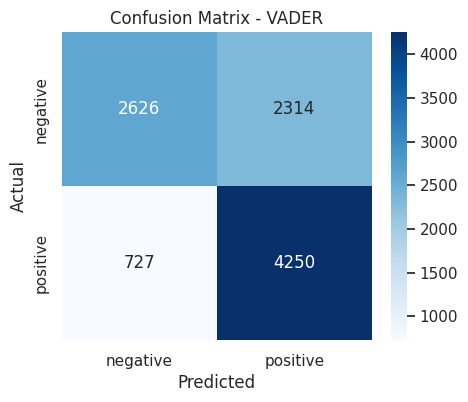

In [38]:
# evaluate vader using the same metrics
acc_vader, prec_vader, rec_vader, f1_vader = get_metrics(y_test, y_pred_vader)
print(f"VADER - Accuracy: {acc_vader:.4f}, Precision: {prec_vader:.4f}, Recall: {rec_vader:.4f}, F1: {f1_vader:.4f}")
plot_confusion_matrix(y_test, y_pred_vader, "VADER")

### Machine Learning: Logistic Regression

We reuse Logistic Regression from Q3 as the machine learning approach, since it already learned from the full TF-IDF vocabulary (136,532 features) and achieved strong results.This avoids retraining a redundant model.

In [39]:
# reuse logistic regression results already computed in q3, no retraining needed
print(f"Logistic Regression - Accuracy: {acc_log_reg:.4f}, Precision: {prec_log_reg:.4f}, Recall: {rec_log_reg:.4f}, F1: {f1_log_reg:.4f}")

Logistic Regression - Accuracy: 0.8925, Precision: 0.8929, Recall: 0.8925, F1: 0.8925


### Deep Learning: LSTM

Unlike TF-IDF-based models, an LSTM processes review text as an ordered sequence of
words through an Embedding layer, allowing it to capture word order and context
(e.g. negation like "not good"). This makes it a meaningfully different approach from
the other two.

In [40]:
# convert text into integer sequences, keeping only the top 10000 most frequent words
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tf.random.set_seed(42)
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# pad sequences to a fixed length of 200 words
X_train_pad = pad_sequences(X_train_seq, maxlen=200, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=200, padding='post', truncating='post')
print(f"Padded training shape: {X_train_pad.shape}")
print(f"Padded testing shape: {X_test_pad.shape}")

Padded training shape: (39665, 200)
Padded testing shape: (9917, 200)


In [41]:
# build a simple lstm mode that consists of embedding layer, lstm layer, then a single output neuron
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

lstm_model = Sequential([Embedding(input_dim=10000, output_dim=64, input_length=200),LSTM(64),Dense(1, activation='sigmoid')])
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [42]:
# convert sentiment labels into binary (0 = negative, 1 = positive) for training
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True)
y_train_binary = y_train.map({'negative': 0, 'positive': 1})
y_test_binary = y_test.map({'negative': 0, 'positive': 1})

history = lstm_model.fit(X_train_pad, y_train_binary, epochs=10, batch_size=64, validation_split=0.1, callbacks=[early_stop])

Epoch 1/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5099 - loss: 0.6930 - val_accuracy: 0.5193 - val_loss: 0.6927
Epoch 2/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.5376 - loss: 0.6746 - val_accuracy: 0.5440 - val_loss: 0.6744
Epoch 3/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.6238 - loss: 0.6072 - val_accuracy: 0.7265 - val_loss: 0.5834
Epoch 4/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.7509 - loss: 0.5239 - val_accuracy: 0.8152 - val_loss: 0.4575
Epoch 5/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8753 - loss: 0.3096 - val_accuracy: 0.8775 - val_loss: 0.3174
Epoch 6/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9278 - loss: 0.1972 - val_accuracy: 0.8800 - val_loss: 0.3331
Epoch 7/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9496 - loss: 0.1504 - val_accuracy: 0.8775 - val_loss: 0.3494
Epoch 8/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9624 - loss: 0.1178 - val_ac

310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
LSTM - Accuracy: 0.8764, Precision: 0.8770, Recall: 0.8764, F1: 0.8763


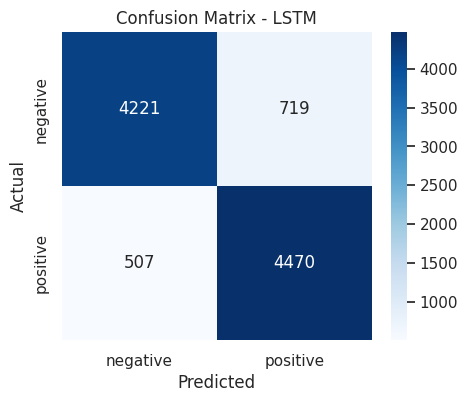

In [43]:
# predict on the test set and convert probabilities back to positive/negative labels
y_pred_prob = lstm_model.predict(X_test_pad)
y_pred_lstm = pd.Series((y_pred_prob > 0.5).astype(int).flatten()).map({0: 'negative', 1: 'positive'})

# evaluate using the same metrics function
acc_lstm, prec_lstm, rec_lstm, f1_lstm = get_metrics(y_test, y_pred_lstm)
print(f"LSTM - Accuracy: {acc_lstm:.4f}, Precision: {prec_lstm:.4f}, Recall: {rec_lstm:.4f}, F1: {f1_lstm:.4f}")
plot_confusion_matrix(y_test, y_pred_lstm, "LSTM")

In [44]:
# comparison table between three models
sentiment_comparison_df = pd.DataFrame({
    'Model': ['VADER (Lexicon)', 'Logistic Regression (ML)', 'LSTM (Deep Learning)'],
    'Accuracy': [acc_vader, acc_log_reg, acc_lstm],
    'Precision': [prec_vader, prec_log_reg, prec_lstm],
    'Recall': [rec_vader, rec_log_reg, rec_lstm],
    'F1-Score': [f1_vader, f1_log_reg, f1_lstm]
})
display(sentiment_comparison_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,VADER (Lexicon),0.693355,0.715072,0.693355,0.685097
1,Logistic Regression (ML),0.892508,0.892855,0.892508,0.892477
2,LSTM (Deep Learning),0.876374,0.877044,0.876374,0.876308


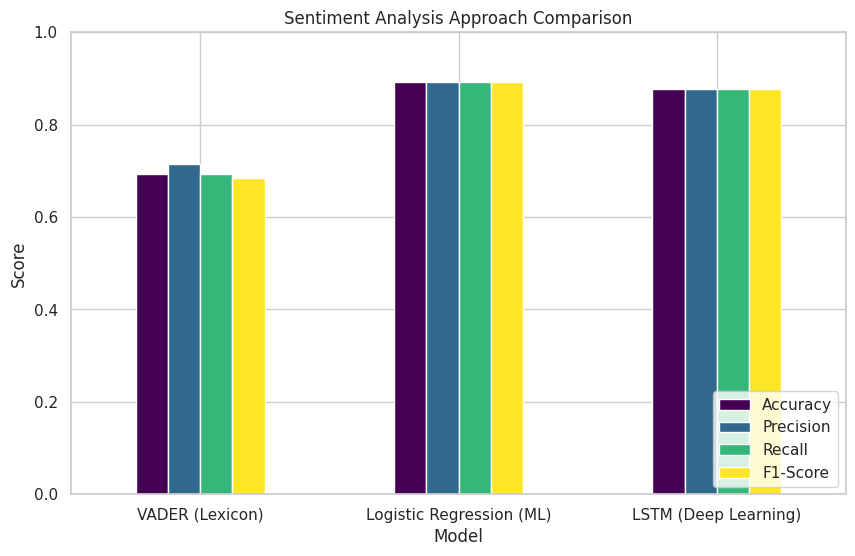

In [45]:
# visualize comparison between three sentiment analysis methods
sentiment_comparison_df.set_index('Model').plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title("Sentiment Analysis Approach Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()

### Pros and Cons Summary

- **VADER**:

    **Pros:** instant, no training required, interpretable

    **Cons:** ignores context and learned patterns from data.
- **Logistic Regression**:

    **Pros:** high accuracy, fast to train, interpretable feature weights

    **Cons:**  treats words independently, ignoring order.
- **LSTM**:

    **Pros:** captures word order and context, learns its own word representations

   **Cons:** requires more setup (tokenization, padding) and longer training time.

## Q6: Comparative Report and Discussion

This section summarizes and compares results across all three tasks — classification,
clustering, and sentiment analysis — using the metrics already computed in Q3-Q5.

In [46]:
# pick the best result from each task using variables already computed in q3-q5
summary_df = pd.DataFrame({
    'Task': ['Classification', 'Classification', 'Classification',
              'Clustering', 'Clustering', 'Clustering',
              'Sentiment Analysis', 'Sentiment Analysis', 'Sentiment Analysis'],
    'Model': ['Logistic Regression', 'Naive Bayes', 'Linear SVM',
              'KMeans', 'Agglomerative', 'GMM',
              'VADER', 'Logistic Regression', 'LSTM'],
    'Metric': ['Accuracy', 'Accuracy', 'Accuracy',
               'Silhouette', 'Silhouette', 'Silhouette',
               'Accuracy', 'Accuracy', 'Accuracy'],
    'Score': [acc_log_reg, acc_nb, acc_svm,
              kmeans_silhouette, agglo_silhouette, gmm_silhouette,
              acc_vader, acc_log_reg, acc_lstm]
})
display(summary_df)

,Task,Model,Metric,Score
0,Classification,Logistic Regression,Accuracy,0.892508
1,Classification,Naive Bayes,Accuracy,0.866593
2,Classification,Linear SVM,Accuracy,0.895432
3,Clustering,KMeans,Silhouette,0.435915
4,Clustering,Agglomerative,Silhouette,0.387315
5,Clustering,GMM,Silhouette,0.434765
6,Sentiment Analysis,VADER,Accuracy,0.693355
7,Sentiment Analysis,Logistic Regression,Accuracy,0.892508
8,Sentiment Analysis,LSTM,Accuracy,0.876374


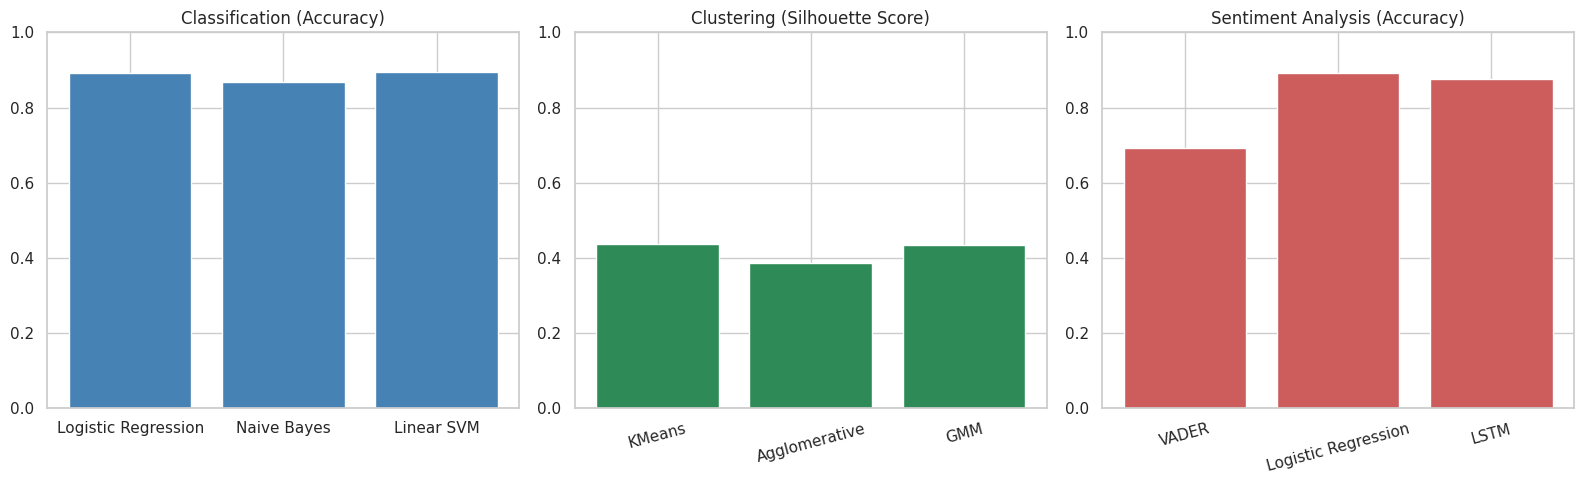

In [47]:
# plot each task's results separately since silhouette and accuracy are different scales
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

classification_scores = summary_df[summary_df['Task'] == 'Classification']
axes[0].bar(classification_scores['Model'], classification_scores['Score'], color='steelblue')
axes[0].set_title("Classification (Accuracy)")
axes[0].set_ylim(0, 1)

clustering_scores = summary_df[summary_df['Task'] == 'Clustering']
axes[1].bar(clustering_scores['Model'], clustering_scores['Score'], color='seagreen')
axes[1].set_title("Clustering (Silhouette Score)")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)

sentiment_scores = summary_df[summary_df['Task'] == 'Sentiment Analysis']
axes[2].bar(sentiment_scores['Model'], sentiment_scores['Score'], color='indianred')
axes[2].set_title("Sentiment Analysis (Accuracy)")
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Which Models Performed Best and Why

- **Classification:** Linear SVM performed best (89.54% accuracy), slightly ahead of
  Logistic Regression (89.25%) and Naive Bayes (86.66%). SVM's margin-based approach
  handles high-dimensional sparse TF-IDF data well, while Naive Bayes' independence
  assumption between words limits its accuracy.
- **Clustering:** KMeans (0.4359) and GMM (0.4348) performed almost identically, both
  clearly ahead of Agglomerative Clustering (0.3873). This suggests the data naturally
  forms two well-separated groups regardless of whether assignment is based on distance
  (KMeans) or probability (GMM).
- **Sentiment Analysis:** Logistic Regression was the strongest (89.25%), ahead of LSTM
  (87.64%) and VADER (69.34%). The full TF-IDF vocabulary gave Logistic Regression more
  precise word-level information than the LSTM's limited vocabulary and fixed sequence
  length, while VADER's rule-based scoring struggled with nuanced review language.

### Challenges Faced During Preprocessing and Model Training

- Raw reviews contained leftover HTML tags (`<br /><br />`), found during EDA as a top
  "word" — required explicit cleanup before tokenization.
- TF-IDF produced 136,532 features; this high dimensionality made clustering and the
  Dense neural network impractical, so TruncatedSVD was used to reduce dimensions.
- Agglomerative Clustering does not scale to the full dataset, requiring a 3,000-row
  subsample, while KMeans and GMM both ran on the full dataset without issue.
- The LSTM initially overfit (training accuracy 98% vs validation accuracy ~85%); early
  stopping with `restore_best_weights=True` corrected this, improving test accuracy from
  82.5% to 87.44%.

### Scalability and Suitability in Real-World Applications

- **Naive Bayes & Logistic Regression:** Lightweight, fast to train even on large
  vocabularies — well-suited for production systems with frequent retraining.
- **Linear SVM:** Slightly higher accuracy but slower to train at scale.
- **KMeans & GMM:** Both scale well to large datasets and produced nearly identical
  results here; **Agglomerative Clustering** does not scale, due to pairwise distance
  computation, limiting it to smaller datasets or sampled data.
- **VADER:** Instant, no training needed — ideal for quick, low-resource sentiment
  checks, but less accurate.
- **LSTM:** Captures context and word order better than TF-IDF models, but needs more
  data, GPU resources, and tuning — better suited where context matters most (e.g.
  sarcasm-heavy text) and resources are available.